In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración global
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
})


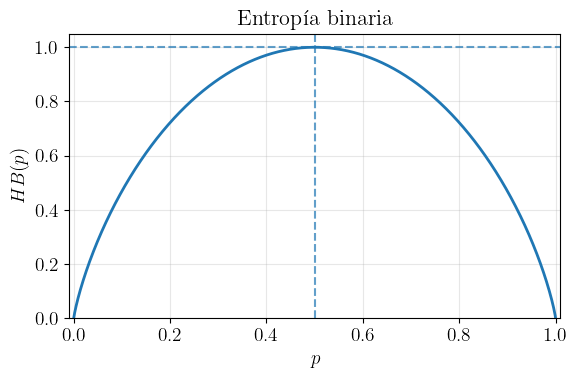

In [ ]:
# Dominio
p = np.linspace(1e-6, 1 - 1e-6, 1000)
H = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

# Figura
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(p, H, lw=2)
ax.axvline(0.5, ls="--", alpha=0.7)
ax.axhline(1,ls="--", alpha=0.7)

ax.set_xlabel(r"$p$")
ax.set_ylabel(r"$HB(p)$")
ax.set_title("Entropía binaria")
ax.set_xlim(-0.01,1.01)
ax.set_ylim(0,1.05)

ax.grid(alpha=0.3)
fig.tight_layout()

plt.show()

In [3]:
import base64
import requests
from IPython.display import Image, display

# 1. Definir el código de tu diagrama conceptual
mermaid_graph = """
graph TD
    %% Estilos globales
    classDef inicio fin fill:#f9f,stroke:#333,stroke-width:2px;
    classDef proceso fill:#bbf,stroke:#333,stroke-width:1px;
    classDef decision fill:#ffb,stroke:#333,stroke-width:1px;
    
    %% Nodos
    Start([Inicio: Estado Inicial]) --> InitVars[Definir Parámetros del Modelo<br>- Población Inicial N0<br>- Tasa de Crecimiento tau]
    
    subgraph Dinámica_Biológica [Proceso Dinámico Estocástico]
        InitVars --> Step[Paso de Tiempo Diferencial dt]
        Step --> CalcProb[Calcular Crecimiento Binomial<br>ΔN ~ Binomial N, p]
        CalcProb --> UpdateN[Actualizar Población<br>N = N + ΔN]
        UpdateN --> CheckTime{¿Se alcanzó el<br>tiempo final T1?}
        CheckTime -- No --> Step
    end

    subgraph Proceso_Observacional [Modelo de Observación y Medición]
        CheckTime -- Sí --> SelectPoints[Definir Puntos de Medición<br>Instantes específicos del experimento]
        SelectPoints --> Interpolate[Extracción de Datos Reales<br>Población real en los instantes elegidos]
        Interpolate --> AddNoise[Modelo de Error Multiplicativo<br>Aplicar Ruido Log-Normal]
        AddNoise --> FloorFilter[Filtro de Umbral Mínimo<br>Asegurar N >= 1]
    end

    FloorFilter --> End([Fin: Datos Observados<br>Resultados Experimentales Simulados])

    %% Aplicación de clases
    class Start,End inicio;
    class InitVars,Step,CalcProb,UpdateN,SelectPoints,Interpolate,AddNoise,FloorFilter proceso;
    class CheckTime decision;
"""

# 2. Codificar el diagrama en formato seguro para URLs (base64)
graphbytes = mermaid_graph.encode("utf-8")
base64_bytes = base64.b64encode(graphbytes)
base64_string = base64_bytes.decode("utf-8")

# 3. URL del servicio oficial de renderizado de Mermaid
# Podés cambiar '.png' por '.svg' si preferís un gráfico vectorial ajustable
url = f"https://mermaid.ink/png/{base64_string}"

# 4. Descargar la imagen y guardarla en tu disco local
response = requests.get(url)
if response.status_code == 200:
    nombre_archivo = "modelo_colonia_flowchart.png"
    with open(nombre_archivo, "wb") as f:
        f.write(response.content)
    print(f"¡Listo! El diagrama se guardó exitosamente como '{nombre_archivo}'")
    
    # 5. Mostrarlo en el Notebook para verificar que todo esté bien
    display(Image(nombre_archivo))
else:
    print("Hubo un problema al generar la imagen desde el servidor de Mermaid.")

Hubo un problema al generar la imagen desde el servidor de Mermaid.


```
graph TD
    Start([Inicio: Estado Inicial]) --> InitVars[Definir Parámetros del Modelo]
    InitVars --> Step[Paso de Tiempo Diferencial dt]
    Step --> CalcProb[Calcular Crecimiento Binomial]
    CalcProb --> UpdateN[Actualizar Población]
    UpdateN --> CheckTime{¿T1?}
    CheckTime -- No --> Step
    CheckTime -- Sí --> End([Fin])
"""